# TA02 — Calibração de Câmera

Este notebook é a camada de explicação, execução e visualização. A implementação reutilizável fica nos módulos Python em `calibration/`.


In [1]:
# ===== IMPORTS =====
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

from calibration.camera import (
    calibrate_camera,
    collect_calibration_points,
    create_object_points,
    create_undistortion_maps,
    detect_corners,
    estimate_board_pose,
    project_board_points,
    undistort_image,
)
from calibration.config import CalibrationConfig, DatasetPaths, Experiment3DConfig
from calibration.image_io import list_images, load_image, pair_stereo_images
from calibration.stereo import (
    calibrate_stereo,
    collect_stereo_results,
    compare_triangulation_with_pnp,
    triangulate_points,
)
from calibration.reporting import (
    compare_with_ground_truth,
    create_output_archive,
    print_output_contents,
    print_summary,
    save_calibration_results,
    save_figure,
)
from calibration.synthetic import SyntheticConfig, generate_synthetic_images


In [2]:
# ===== CONFIGURAÇÕES =====
config = CalibrationConfig(
    board_corners=(9, 4),
    square_size_mm=90,
    device="android",
    colab=False,
    use_synthetic=True,
    alpha=1.0,
)
if not config.colab:
    config.root_dir = Path("data")
paths = DatasetPaths(config.root_dir, config.use_synthetic, config.device)
experiment_3d = Experiment3DConfig()

syn_config = SyntheticConfig(
    width = 1600,
    height = 1200,
    K = np.array([[1400.0, 0, 810.0],
                  [0, 1395.0, 590.0],
                  [0, 0, 1.0]]),
    distortion = np.array([-0.28, 0.12, 0.001, -0.0015, -0.02]),
    stereo_distance = 120.0,
    pixels_per_square = 60
)

print("Cantos internos:", config.board_corners)
print("Quadrado:", config.square_size_mm, "mm")
print("Lendo de:", paths.input)
print("Gravando em:", paths.output)


Cantos internos: (9, 4)
Quadrado: 90 mm
Lendo de: data/synthetic/input
Gravando em: data/synthetic/output


In [3]:
# ===== ENVIO DAS FOTOS (OPCIONAL) =====
# A implementação de upload fica em calibration.image_io.
# from calibration.image_io import upload_images
# if not config.use_synthetic:
#     upload_images(paths.calibration)
#     upload_images(paths.test)


## Gerador de Fotos Sintéticas

As imagens sintéticas validam a calibração usando uma matriz intrínseca e parâmetros de distorção conhecidos.


In [4]:
if config.use_synthetic:
    generate_synthetic_images(num_calib = 25, 
                              num_test = 3, 
                              num_stereo = 12, 
                              dataset_paths = paths, 
                              calibration_config = config, 
                              synthetic_config = syn_config)

25 de calibração, 3 de teste, 12 pares estéreoteste


In [5]:
# ===== LEITURA DAS IMAGENS =====
calibration_images = list_images(paths.calibration)
test_images = list_images(paths.test)
if not calibration_images:
    raise RuntimeError(f"Nenhuma imagem de calibração encontrada em {paths.calibration}")
image_size = load_image(calibration_images[0]).shape[:2][::-1]
print(len(calibration_images), "fotos de calibração |", len(test_images), "de teste")
print("resolução:", image_size)


25 fotos de calibração | 3 de teste
resolução: (1600, 1200)


In [6]:
# ===== DETECÇÃO DOS CANTOS =====
object_points = create_object_points(config.board_corners, config.square_size_mm)
obj_pts, img_pts, used_images, detected_image_size = collect_calibration_points(
    calibration_images,
    config.board_corners,
    config.square_size_mm,
)
print(f"tabuleiro detectado em {len(used_images)} de {len(calibration_images)} fotos")


tabuleiro detectado em 25 de 25 fotos


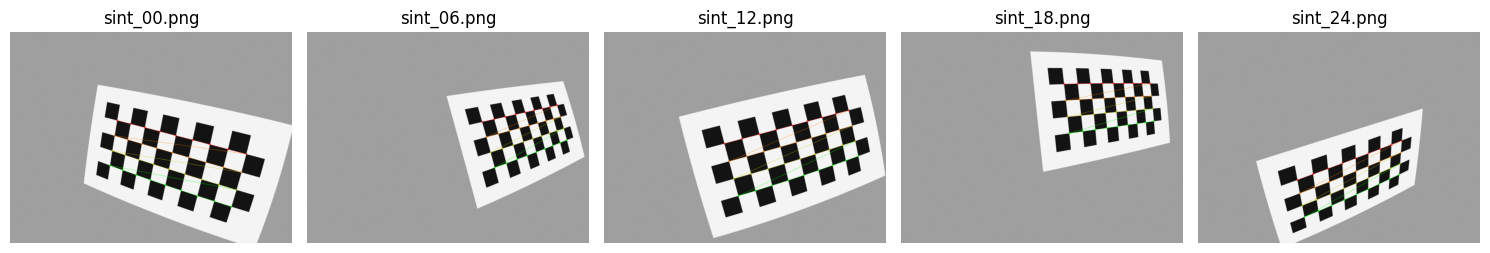

In [7]:
# ===== EXEMPLOS DA DETECÇÃO =====
fig, axes = plt.subplots(1, min(5, len(used_images)), figsize=(15, 4))
axes = np.atleast_1d(axes)
indices = np.linspace(0, len(used_images)-1, len(axes), dtype=int)
for axis, index in zip(axes, indices):
    image = load_image(used_images[index])
    drawn = cv2.drawChessboardCorners(image.copy(), config.board_corners, img_pts[index], True)
    axis.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    axis.set_title(Path(used_images[index]).name)
    axis.axis("off")
plt.tight_layout()
save_figure("deteccao_cantos.png", paths.figures)
plt.show()


erro RMS de reprojeção: 0.0448 px
K =
 [[1.39987440e+03 0.00000000e+00 8.09956041e+02]
 [0.00000000e+00 1.39481433e+03 5.90126302e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distorção [k1 k2 p1 p2 k3] = [-0.27881458  0.11381377  0.00097277 -0.0015391  -0.00842932]
campo de visão: 59.5° x 46.6°
erro médio por imagem: 0.0400 px


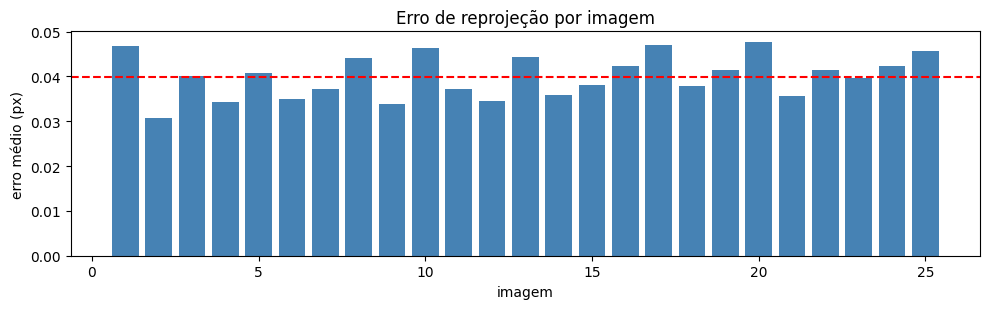

In [8]:
# ===== CALIBRAÇÃO =====
calibration = calibrate_camera(obj_pts, img_pts, detected_image_size)
print(f"erro RMS de reprojeção: {calibration.rms:.4f} px")
print("K =\n", calibration.camera_matrix)
print("distorção [k1 k2 p1 p2 k3] =", calibration.distortion)
print(f"campo de visão: {calibration.fov_x:.1f}° x {calibration.fov_y:.1f}°")
print(f"erro médio por imagem: {calibration.reprojection_errors.mean():.4f} px")

plt.figure(figsize=(10, 3.2))
plt.bar(range(1, len(calibration.reprojection_errors)+1), calibration.reprojection_errors, color="steelblue")
plt.axhline(calibration.reprojection_errors.mean(), color="r", ls="--")
plt.xlabel("imagem")
plt.ylabel("erro médio (px)")
plt.title("Erro de reprojeção por imagem")
plt.tight_layout()
save_figure("erro_por_imagem.png", paths.figures)
plt.show()


In [9]:
# ===== COMPARAÇÃO COM A VERDADE SINTÉTICA =====
resultados = {
    "n_fotos": len(calibration_images),
    "n_usadas": len(used_images),
    "rms": calibration.rms,
    "K": calibration.camera_matrix.tolist(),
    "dist": calibration.distortion.tolist(),
    "fov": [calibration.fov_x, calibration.fov_y],
    "erro_medio": float(calibration.reprojection_errors.mean()),
    "erro_max": float(calibration.reprojection_errors.max()),
    "tam": list(calibration.image_size),
}
compare_with_ground_truth(config, paths, calibration.camera_matrix, calibration.distortion, resultados)


           real   estimado      erro
fx    1400.0000  1399.8744   -0.1256
fy    1395.0000  1394.8143   -0.1857
cx     810.0000   809.9560   -0.0440
cy     590.0000   590.1263    0.1263
k1      -0.2800    -0.2788    0.0012
k2       0.1200     0.1138   -0.0062
p1       0.0010     0.0010   -0.0000
p2      -0.0015    -0.0015   -0.0000
k3      -0.0200    -0.0084    0.0116


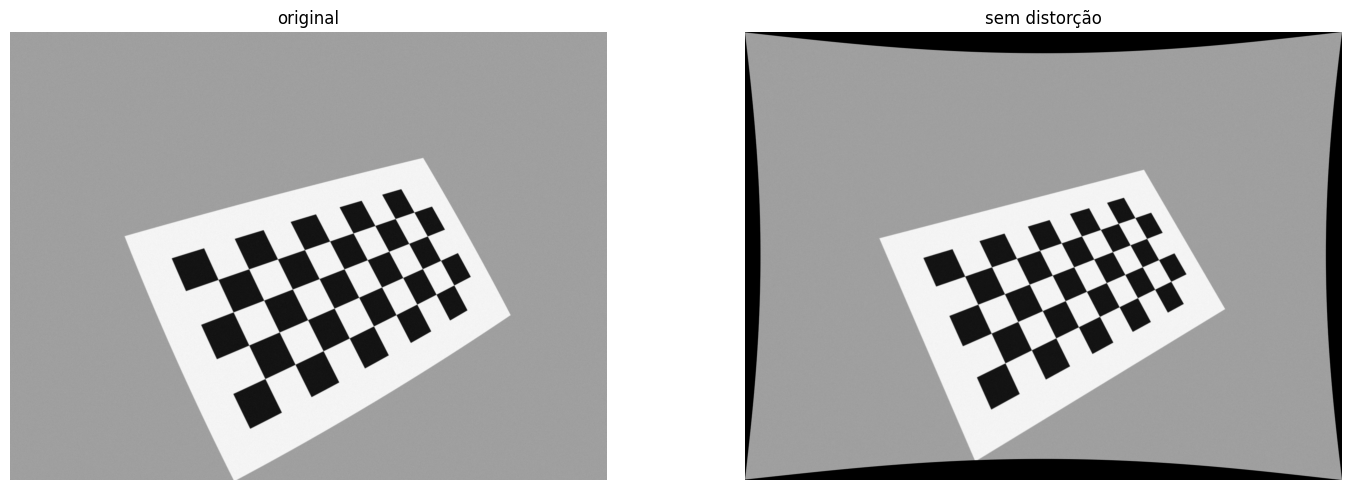

In [10]:
# ===== REMOÇÃO DA DISTORÇÃO =====
undistortion_maps = create_undistortion_maps(
    calibration.camera_matrix,
    calibration.distortion,
    calibration.image_size,
    config,
)
original = load_image(used_images[1])
corrected = undistort_image(original, undistortion_maps)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)); axes[1].set_title("sem distorção"); axes[1].axis("off")
plt.tight_layout()
save_figure("remocao_distorcao.png", paths.figures)
plt.show()


## Campo de distorção

A visualização usa a matriz calibrada e os coeficientes de distorção.


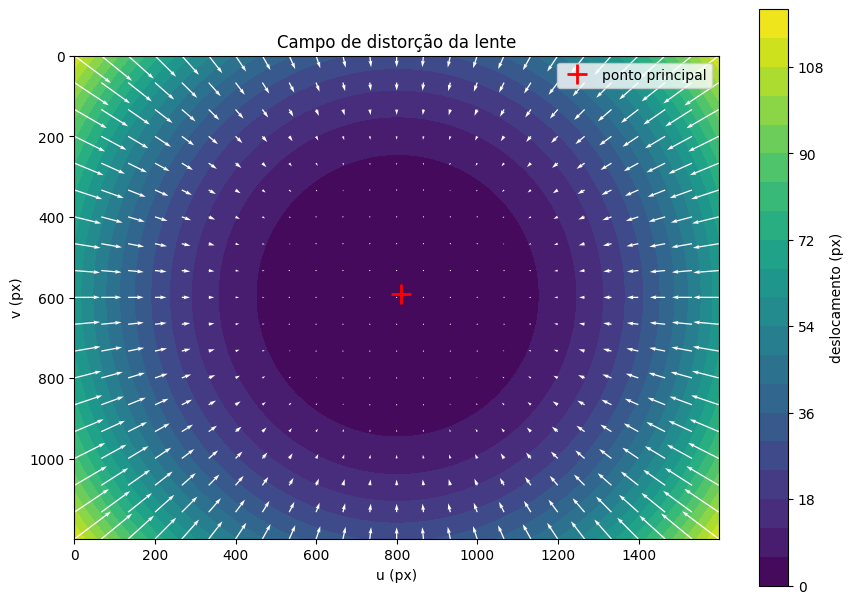

deslocamento máximo: 114.4 px


In [11]:
# ===== CAMPO DE DISTORÇÃO =====
gx, gy = np.meshgrid(
    np.linspace(0, calibration.image_size[0]-1, 25),
    np.linspace(0, calibration.image_size[1]-1, 19),
)
ideal = np.stack([gx.ravel(), gy.ravel()], 1).astype(np.float32)
raio = cv2.undistortPoints(ideal.reshape(-1,1,2), calibration.camera_matrix, np.zeros(5)).reshape(-1,2)
raio3 = np.hstack([raio, np.ones((len(raio), 1))])
real_px = cv2.projectPoints(raio3, np.zeros(3), np.zeros(3), calibration.camera_matrix, calibration.distortion)[0].reshape(-1,2)
deslocamento = real_px - ideal
fx_grid, fy_grid = np.meshgrid(
    np.linspace(0, calibration.image_size[0]-1, 160),
    np.linspace(0, calibration.image_size[1]-1, 120),
)
grid = np.stack([fx_grid.ravel(), fy_grid.ravel()], axis=1).astype(np.float32)
grid_rays = cv2.undistortPoints(
    grid.reshape(-1, 1, 2), calibration.camera_matrix, np.zeros(5)
).reshape(-1, 2)
grid_pixels = cv2.projectPoints(
    np.hstack([grid_rays, np.ones((len(grid_rays), 1))]),
    np.zeros(3), np.zeros(3), calibration.camera_matrix, calibration.distortion,
)[0].reshape(-1, 2)
magnitude = np.linalg.norm(grid_pixels - grid, axis=1).reshape(fx_grid.shape)
fig, axis = plt.subplots(figsize=(9, 6.2))
contours = axis.contourf(fx_grid, fy_grid, magnitude, levels=20, cmap="viridis")
fig.colorbar(contours, ax=axis, label="deslocamento (px)")
axis.quiver(ideal[:, 0], ideal[:, 1], deslocamento[:, 0], deslocamento[:, 1],
            color="white", angles="xy", scale_units="xy", scale=1, width=0.002)
axis.plot(calibration.camera_matrix[0, 2], calibration.camera_matrix[1, 2],
          "r+", ms=14, mew=2, label="ponto principal")
axis.invert_yaxis()
axis.set_aspect("equal")
axis.set_xlabel("u (px)")
axis.set_ylabel("v (px)")
axis.set_title("Campo de distorção da lente")
axis.legend(loc="upper right")
fig.tight_layout()
save_figure("campo_distorcao.png", paths.figures)
plt.show()
resultados["desl_max"] = float(magnitude.max())
print(f"deslocamento máximo: {magnitude.max():.1f} px")


sint_teste_00.png: distância 1493 mm | erro com distorção 0.058 px (máx 0.137) | sem distorção 12.97 px
sint_teste_01.png: distância 1327 mm | erro com distorção 0.039 px (máx 0.067) | sem distorção 20.98 px
sint_teste_02.png: distância 1407 mm | erro com distorção 0.086 px (máx 0.205) | sem distorção 17.45 px


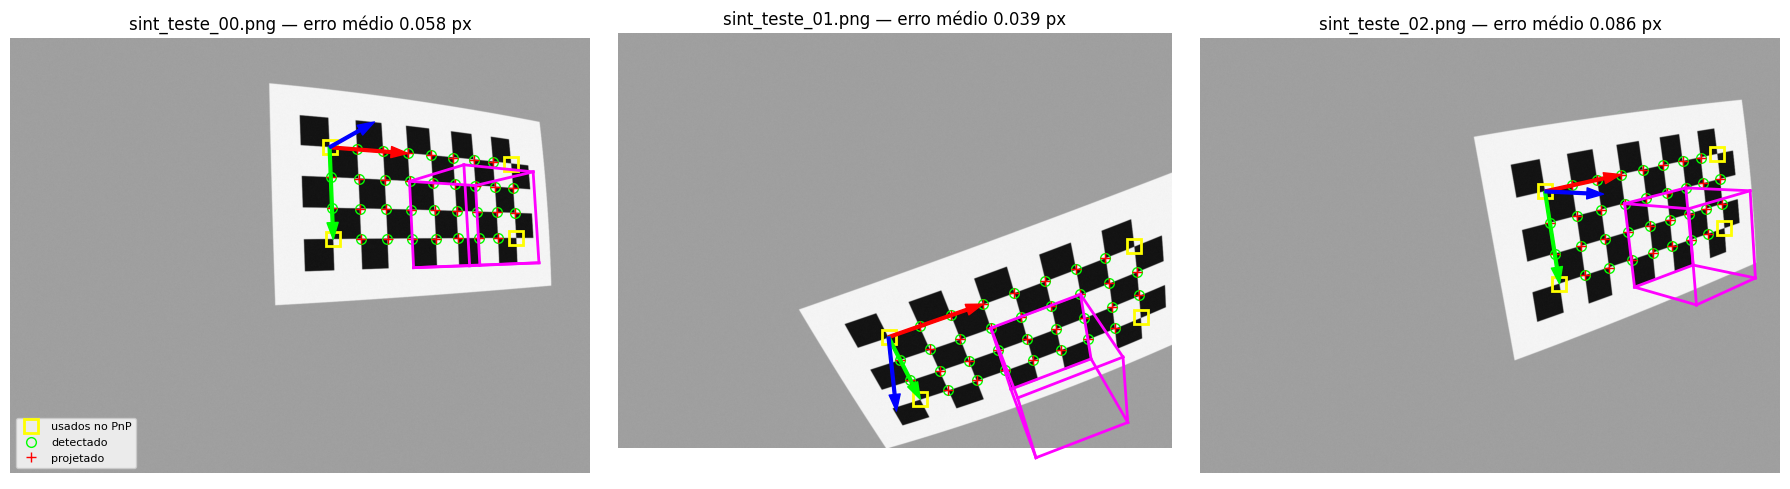

In [12]:
# ===== EXPERIMENTO 3D -> 2D =====
external_ids = [
    0,
    config.board_corners[0] - 1,
    config.board_corners[0] * (config.board_corners[1] - 1),
    len(object_points) - 1,
]
internal_ids = [i for i in range(len(object_points)) if i not in external_ids]
square_size = config.square_size_mm
cube_x = experiment_3d.cube_origin_squares[0] * square_size
cube_y = experiment_3d.cube_origin_squares[1] * square_size
cube_side = experiment_3d.cube_side_squares * square_size
cube_base = np.array([
    [cube_x, cube_y, 0],
    [cube_x + cube_side, cube_y, 0],
    [cube_x + cube_side, cube_y + cube_side, 0],
    [cube_x, cube_y + cube_side, 0],
], dtype=np.float32)
cube_top = cube_base.copy()
cube_top[:, 2] = experiment_3d.cube_depth_direction * cube_side
cube_points = np.vstack([cube_base, cube_top])
cube_edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7),
]
axis_points = np.float32([
    [0, 0, 0],
    [experiment_3d.axis_length_squares * square_size, 0, 0],
    [0, experiment_3d.axis_length_squares * square_size, 0],
    [0, 0, experiment_3d.cube_depth_direction * experiment_3d.axis_length_squares * square_size],
])
experiment_images = test_images or used_images[-3:]
experiment_rows = []
fig, axes = plt.subplots(1, len(experiment_images), figsize=(6 * len(experiment_images), 4.8))
axes = np.atleast_1d(axes)
for axis, path in zip(axes, experiment_images):
    image = load_image(path)
    corners = detect_corners(image, config.board_corners)
    if corners is None:
        print("tabuleiro não detectado:", path)
        axis.axis("off")
        continue
    corners = corners.reshape(-1, 2)
    ok, rvec, tvec = estimate_board_pose(
        object_points[external_ids], corners[external_ids],
        calibration.camera_matrix, calibration.distortion,
    )
    projected = project_board_points(
        object_points, rvec, tvec, calibration.camera_matrix, calibration.distortion
    )
    projected_without_distortion = project_board_points(
        object_points, rvec, tvec, calibration.camera_matrix, np.zeros(5)
    )
    projected_cube = project_board_points(
        cube_points, rvec, tvec, calibration.camera_matrix, calibration.distortion
    )
    projected_axes = project_board_points(
        axis_points, rvec, tvec, calibration.camera_matrix, calibration.distortion
    )
    errors = np.linalg.norm(projected[internal_ids] - corners[internal_ids], axis=1)
    errors_without_distortion = np.linalg.norm(
        projected_without_distortion[internal_ids] - corners[internal_ids], axis=1
    )
    distance = float(np.linalg.norm(tvec))
    experiment_rows.append([
        Path(path).name, distance, float(errors.mean()), float(errors.max()),
        float(errors_without_distortion.mean()),
    ])
    print(
        f"{Path(path).name}: distância {distance:.0f} mm | "
        f"erro com distorção {errors.mean():.3f} px "
        f"(máx {errors.max():.3f}) | sem distorção "
        f"{errors_without_distortion.mean():.2f} px"
    )
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.plot(corners[external_ids, 0], corners[external_ids, 1], "s",
              mfc="none", mec="yellow", ms=10, mew=2, label="usados no PnP")
    axis.plot(corners[internal_ids, 0], corners[internal_ids, 1], "o",
              mfc="none", mec="lime", ms=7, label="detectado")
    axis.plot(projected[internal_ids, 0], projected[internal_ids, 1], "r+",
              ms=7, label="projetado")
    for start, end in cube_edges:
        axis.plot(projected_cube[[start, end], 0], projected_cube[[start, end], 1],
                  color="magenta", lw=2)
    for endpoint, color in zip(projected_axes[1:], ["red", "lime", "blue"]):
        axis.annotate("", endpoint, projected_axes[0],
                      arrowprops={"color": color, "width": 2, "headwidth": 8})
    axis.set_title(f"{Path(path).name} — erro médio {errors.mean():.3f} px")
    axis.axis("off")
if experiment_rows:
    axes[0].legend(loc="lower left", fontsize=8)
    resultados["experimento"] = experiment_rows
    save_figure("projecao_3d.png", paths.figures)
plt.tight_layout()
plt.show()


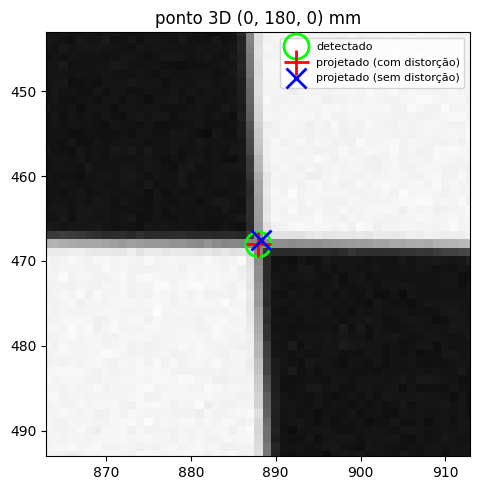

In [13]:
# ===== AMPLIAÇÃO: DETECTADO X PROJETADO =====
if experiment_images and experiment_rows:
    zoom_path = experiment_images[0]
    zoom_image = load_image(zoom_path)
    zoom_corners = detect_corners(zoom_image, config.board_corners)
    if zoom_corners is not None:
        zoom_corners = zoom_corners.reshape(-1, 2)
        _, zoom_rvec, zoom_tvec = estimate_board_pose(
            object_points[external_ids], zoom_corners[external_ids],
            calibration.camera_matrix, calibration.distortion,
        )
        zoom_projected = project_board_points(
            object_points, zoom_rvec, zoom_tvec,
            calibration.camera_matrix, calibration.distortion,
        )
        zoom_projected_without_distortion = project_board_points(
            object_points, zoom_rvec, zoom_tvec,
            calibration.camera_matrix, np.zeros(5),
        )
        zoom_index = internal_ids[len(internal_ids) // 2]
        x, y = zoom_corners[zoom_index]
        radius = 25
        fig, axis = plt.subplots(figsize=(5, 5))
        axis.imshow(cv2.cvtColor(zoom_image, cv2.COLOR_BGR2RGB), interpolation="nearest")
        axis.plot(*zoom_corners[zoom_index], "o", mfc="none", mec="lime", ms=18,
                  mew=2, label="detectado")
        axis.plot(*zoom_projected[zoom_index], "r+", ms=18, mew=2,
                  label="projetado (com distorção)")
        axis.plot(*zoom_projected_without_distortion[zoom_index], "bx", ms=14,
                  mew=2, label="projetado (sem distorção)")
        axis.set_xlim(x - radius, x + radius)
        axis.set_ylim(y + radius, y - radius)
        axis.set_title(
            f"ponto 3D ({object_points[zoom_index, 0]:.0f}, "
            f"{object_points[zoom_index, 1]:.0f}, 0) mm"
        )
        axis.legend(fontsize=8)
        fig.tight_layout()
        save_figure("projecao_zoom.png", paths.figures)
        plt.show()


In [14]:
# ===== CALIBRAÇÃO ESTÉREO (OPCIONAL) =====
stereo_pairs = pair_stereo_images(paths.stereo_left, paths.stereo_right)
print("pares estéreo:", len(stereo_pairs))
if len(stereo_pairs) >= 2:
    left_paths, right_paths = zip(*stereo_pairs)
    stereo_object_points, left_points, right_points = collect_stereo_results(
        left_paths, right_paths, config
    )
    if len(stereo_object_points) >= 2:
        stereo = calibrate_stereo(
            stereo_object_points,
            left_points,
            right_points,
            calibration.camera_matrix,
            calibration.distortion,
            calibration.camera_matrix,
            calibration.distortion,
            calibration.image_size,
        )
        resultados.update({
            "estereo_rms": stereo.rms,
            "estereo_T": stereo.translation.ravel().tolist(),
            "estereo_base": stereo.baseline,
            "estereo_ang": stereo.angle_degrees,
            "estereo_pares": len(stereo_object_points) - 1,
        })
        print(f"RMS estéreo: {stereo.rms:.4f} px")
        print(f"base: {stereo.baseline:.2f} mm | rotação: {stereo.angle_degrees:.3f}°")
        left_test = left_points[-1].reshape(-1, 2)
        right_test = right_points[-1].reshape(-1, 2)
        points_3d = triangulate_points(
            left_test, right_test,
            calibration.camera_matrix, calibration.distortion,
            calibration.camera_matrix, calibration.distortion,
            stereo.rotation, stereo.translation,
        )
        triangulation = compare_triangulation_with_pnp(
            points_3d, stereo.object_points[-1], left_test,
            calibration.camera_matrix, calibration.distortion,
            config.square_size_mm,
        )
        resultados["tri_lado"] = list(triangulation["square_size"][:2])
        resultados["tri_dif"] = list(triangulation["difference"])
        print(
            f"lado triangulado: {triangulation['square_size'][0]:.3f} ± "
            f"{triangulation['square_size'][1]:.3f} mm "
            f"(real {config.square_size_mm:.1f} mm)"
        )
        print(
            f"diferença triangulação x PnP: média "
            f"{triangulation['difference'][0]:.3f} mm, "
            f"máx {triangulation['difference'][1]:.3f} mm"
        )
        chosen = config.board_corners[0] * 2 + 4
        resultados["tri_ponto"] = points_3d[chosen].tolist()
        print(f"ponto escolhido: {np.round(points_3d[chosen], 2)} mm")


pares estéreo: 12
RMS estéreo: 0.0494 px
base: 120.02 mm | rotação: 0.001°
lado triangulado: 145.720 ± 123.578 mm (real 90.0 mm)
diferença triangulação x PnP: média 0.827 mm, máx 2.703 mm
ponto escolhido: [ 315.76   41.9  1543.44] mm


In [15]:
# ===== SALVA TODAS AS FOTOS SEM DISTORÇÃO =====
for path in used_images + test_images:
    corrected = undistort_image(load_image(path), undistortion_maps)
    cv2.imwrite(str(paths.corrected_images / (Path(path).stem + "_corrigida.png")), corrected)
print(len(list(paths.corrected_images.iterdir())), "imagens corrigidas em", paths.corrected_images)


28 imagens corrigidas em data/synthetic/output/corrected_images


In [16]:
# ===== MÉTRICAS E RELATÓRIO =====
# CalibrationResults ainda não expõe std_int; o vetor abaixo é provisório.
std_int = np.zeros(9)
latex_lines = save_calibration_results(calibration, std_int, resultados, paths.metrics)
print_summary(calibration, resultados, latex_lines)
print_output_contents(paths.output)


===== RESUMO =====
fotos: 25/25 | resolução 1600x1200
fx=1399.87 fy=1394.81 cx=809.96 cy=590.13
dist = [-0.27881  0.11381  0.00097 -0.00154 -0.00843]
RMS = 0.0448 px | FOV 59.5° x 46.6°

--- tabelas LaTeX (também em dados/tabelas_latex.txt) ---
$f_x$ (px) & 1399{,}87 & 0{,}00 \\
$f_y$ (px) & 1394{,}81 & 0{,}00 \\
$c_x$ (px) & 809{,}96 & 0{,}00 \\
$c_y$ (px) & 590{,}13 & 0{,}00 \\
$k_1$ & -0{,}2788 & 0{,}0000 \\
$k_2$ & 0{,}1138 & 0{,}0000 \\
$p_1$ & 0{,}0010 & 0{,}0000 \\
$p_2$ & -0{,}0015 & 0{,}0000 \\
$k_3$ & -0{,}0084 & 0{,}0000 \\
RMS (px) & \multicolumn{2}{c}{0{,}045} \\

% experimento 3D -> 2D
Teste 1 & 1493 & 0{,}058 & 0{,}137 & 12{,}97 \\
Teste 2 & 1327 & 0{,}039 & 0{,}067 & 20{,}98 \\
Teste 3 & 1407 & 0{,}086 & 0{,}205 & 17{,}45 \\

===== CONTEÚDO DA PASTA DE SAÍDA =====
output/ (0 arquivos)
   corrected_images/ (28 arquivos)
   figures/ (6 arquivos)
   metrics/ (4 arquivos)


In [17]:
# ===== ZIP OPCIONAL =====
# archive = create_output_archive(paths.base, paths.output, config.colab)
